Notebook Link: https://colab.research.google.com/drive/1yHH-yVKgJV9_XocclgN21q0HxHP7QIpA?usp=sharing

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import shutil
import cv2

In [4]:
from google.colab import drive, files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip '/content/drive/My Drive/APS360/archive (2).zip' -d '/content/'

In [6]:
allowed_classes = [
    'Basketball', 'CricketShot', 'TennisSwing', 'Bowling', 'BaseballPitch',
    'JavelinThrow', 'Archery', 'PoleVault', 'SoccerPenalty', 'Biking',
    'Skiing', 'Fencing'
]

directories = ['/content/test', '/content/train', '/content/val']

# Loop through folder for each split and delete unwanted class folders
for dir in directories:
  for class_folder in os.listdir(dir):
    full_path = os.path.join(dir, class_folder)

    if class_folder not in allowed_classes:
        shutil.rmtree(full_path)


In [7]:
# Define constants
INPUT_DIR = '/content/'
OUTPUT_DIR = '/content/ucf_dataset_frames'
NUM_FRAMES_PER_VIDEO = 16
TARGET_IMG_SIZE = 224 # This variable is used for resizing again.

# Create output directories if they don't exist
for split_dir in ['train', 'test', 'val']:
    os.makedirs(os.path.join(OUTPUT_DIR, split_dir), exist_ok=True)


def extract_frames(video_path):
  frames = []

  # Open video file
  cap = cv2.VideoCapture(video_path)

  # Return early if error occurs while tyring to open video file
  if not cap.isOpened():
    print(f"Error: could not open video {video_path}")
    return frames

  # See how much frames video currently has
  total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))


  # Uniformly sample NUM_FRAMES_PER_VIDEO frames
  interval = total_frames / NUM_FRAMES_PER_VIDEO
  sampling_indices = [int(i * interval) for i in range(NUM_FRAMES_PER_VIDEO)]

  # Loop through sampling indices
  for i, frame_idx in enumerate(sampling_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()

    # Resize frame to target size
    resized_frame = cv2.resize(frame, (TARGET_IMG_SIZE, TARGET_IMG_SIZE))

    # Frames are appended after resizing, typically uint8 in original 0-255 range.
    frames.append(resized_frame)

  # Close video file
  cap.release()

  return frames

In [8]:
directories = ['train', 'val', 'test']


for split_dir in directories:
  # Get the input and output dir path for current split
  split_input_path = os.path.join(INPUT_DIR, split_dir)
  split_output_path = os.path.join(OUTPUT_DIR, split_dir)

  for class_name in allowed_classes:
    # Create the subdirectory for the current class in the output split directory
    input_class_path = os.path.join(split_input_path, class_name)
    output_class_path = os.path.join(split_output_path, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    # Get all videos in the input split folder of current class
    video_files = [f for f in os.listdir(input_class_path)]

    for video_filename in video_files:
      # For every video get the sampled 16 frames
      video_path = os.path.join(input_class_path, video_filename)
      video_name_without_ext = os.path.splitext(video_filename)[0]
      extracted_frames = extract_frames(video_path)

      if len(extracted_frames) == 0:
        print(f"Skipping corrupted video: {video_path}")
        continue

      # Create a subfolder for this clip
      clip_output_path = os.path.join(output_class_path, video_name_without_ext)
      os.makedirs(clip_output_path, exist_ok=True)

      # For every frame add the frame # to file name and write to class subdirectory in output split directory
      for i, frame in enumerate(extracted_frames):
        # Save frames directly as they come from extract_frames (original resolution, uint8, 0-255 range).
        frame_filename = f"frame_{i:02d}.jpg"
        frame_output_path = os.path.join(clip_output_path, frame_filename)
        cv2.imwrite(frame_output_path, frame)

/content/ucf_dataset_frames/train/TennisSwing/v_TennisSwing_g01_c01


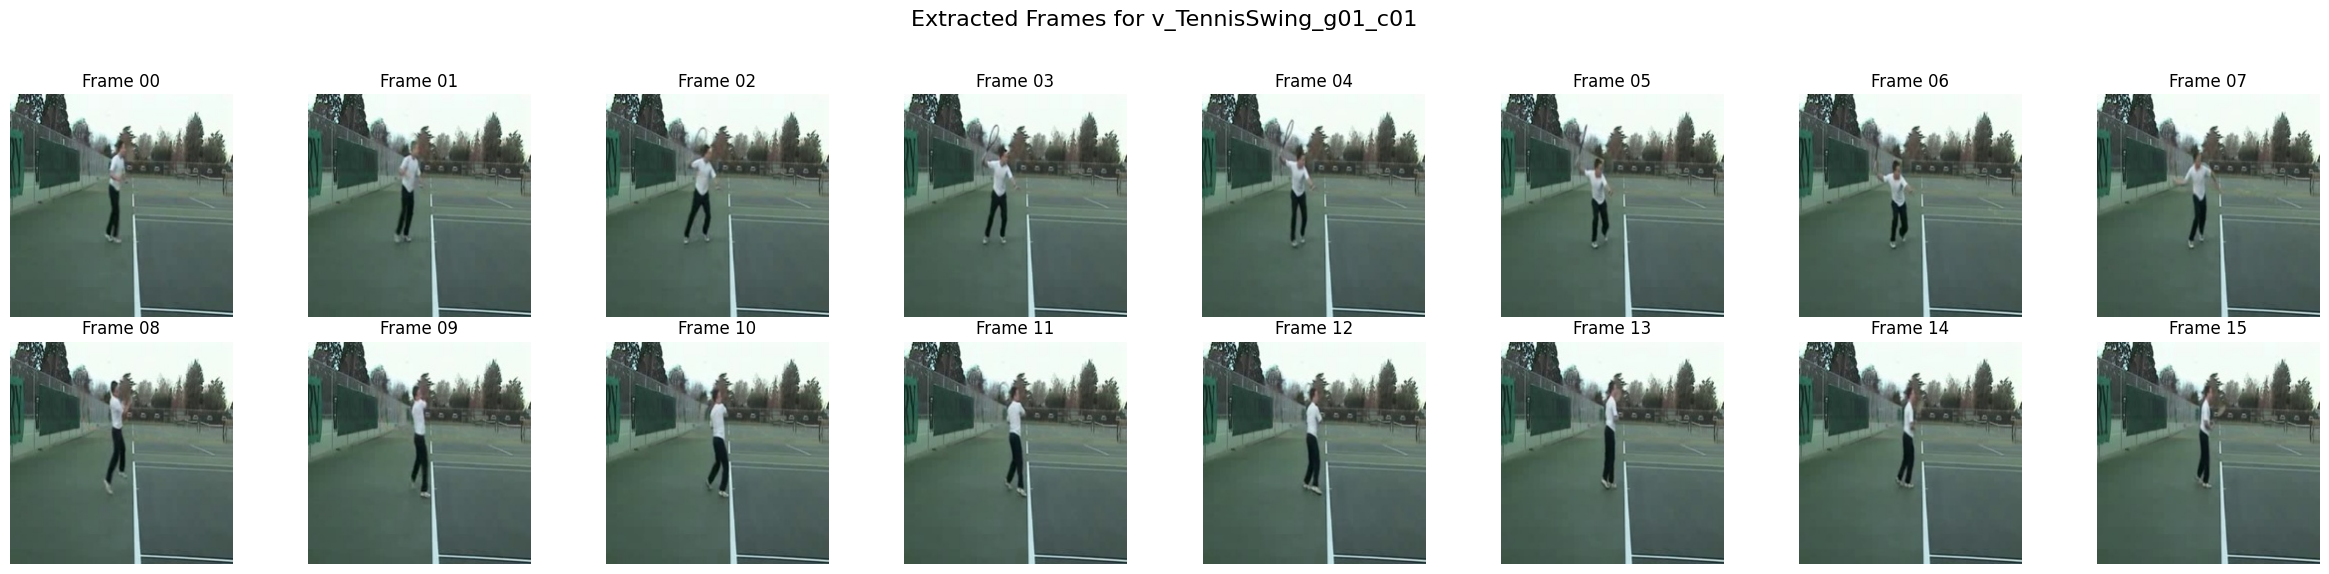

In [9]:
# Example video details from previous execution
example_split_dir = 'train'
example_class_name = 'TennisSwing'
example_video_name_without_ext = 'v_TennisSwing_g01_c01'

# Construct the base path to the frames
example_frames_dir = os.path.join(OUTPUT_DIR, example_split_dir, example_class_name, example_video_name_without_ext)
print(example_frames_dir)

plt.figure(figsize=(24, 6)) # Adjusted figure size for 8 frames per row

loaded_frames_count = 0
for i in range(NUM_FRAMES_PER_VIDEO):
  frame_filename = os.path.join(example_frames_dir, f"frame_{i:02d}.jpg")
  if os.path.exists(frame_filename):
    # Read and convert image from OpenCV format to matplotlib format
    frame = cv2.imread(frame_filename)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Plot image
    plt.subplot(2, 8, i + 1)
    plt.imshow(frame_rgb)
    plt.title(f"Frame {i:02d}")
    plt.axis('off')
    loaded_frames_count += 1

  else:
      print(f"Warning: Frame file not found: {frame_filename}")


plt.suptitle(f"Extracted Frames for {example_video_name_without_ext}", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Example of a cleaned training sample

In [10]:
class_split_counts = {class_name: {'train': 0, 'val': 0, 'test': 0, 'total': 0} for class_name in allowed_classes}

for split_dir in ['train', 'val', 'test']:
  split_path = os.path.join(OUTPUT_DIR, split_dir)
  for class_name in allowed_classes:
    class_path = os.path.join(split_path, class_name)
    count = len([f for f in os.listdir(class_path) if os.path.isdir(os.path.join(class_path, f))])
    class_split_counts[class_name][split_dir] = count
    class_split_counts[class_name]['total'] += count

df_class_counts = pd.DataFrame.from_dict(class_split_counts, orient='index')
df_class_counts

,train,val,test,total
Basketball,198,33,34,265
CricketShot,125,21,21,167
TennisSwing,124,21,21,166
Bowling,116,19,20,155
BaseballPitch,112,19,19,150
JavelinThrow,87,15,15,117
Archery,108,18,19,145
PoleVault,111,19,19,149
SoccerPenalty,102,17,18,137
Biking,100,17,17,134


In [11]:
df_class_counts.to_excel('class_counts.xlsx', index=True)

In [ ]:
!zip -r ucf_dataset_frames.zip /content/ucf_dataset_frames

In [13]:
files.download('ucf_dataset_frames.zip')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
%%shell
jupyter nbconvert --to html /content/aps360_data_processing.ipynb

[NbConvertApp] Converting notebook /content/aps360_data_processing.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 2221491 bytes to /content/aps360_data_processing.html
